In [1]:
from typing import Annotated
from langgraph.graph import StateGraph,START
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image,display
import gradio as gr
from langgraph.prebuilt import ToolNode,tools_condition
import requests
import os
from langchain_openai import ChatOpenAI
from typing import TypedDict

In [2]:
load_dotenv(override=True)

True

In [3]:
from langchain_community.utilities import GoogleSerperAPIWrapper
serper = GoogleSerperAPIWrapper()
serper.run("what are thebsteps for agentic evalution")

'What is Agentic Observability? ___Assess how agents perform tasks and respond to inputs. ___Ensure alignment with key criteria like efficiency, ethical compliance, and user satisfaction. ___Evaluate agents based on responsible AI principles like trust, data privacy, and transparency.'

In [4]:
from langchain_core.tools import Tool
tool_search = Tool(
                name = "search",
                func = serper.run,
                description = "useful for online search"
)

In [8]:
tool_search.invoke("agent monitoring methods")

'Core components of an AI agent monitoring strategy ___Instrumentation and observability layers. The foundation of monitoring is good data. ... ___Logs and traces. Logs and traces turn agent behavior from a black box into something you can analyze. ... ___Key metrics and signals to track. ... ___Safety and compliance checks.'

In [5]:
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_user = os.getenv("PUSHOVER_USER")
pushover_url = "https://api.pushover.net/1/messages.json"
def push(text:str):
    requests.post(pushover_url,data = {"token": pushover_token, "user": pushover_user, "message": text})

In [6]:
tool_push = Tool(
        name = "send_push_notification",
        func = push,
        description = "send a notification"
)

In [10]:
tools = [tool_search,tool_push]

In [11]:
#1 define state object
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [27]:
#2 start the graph builder with state class
graph_builder=StateGraph(State)

In [28]:
llm=ChatOpenAI(model="gpt-4o-mini")
llm_with_tools=llm.bind_tools(tools)

In [29]:
#3 create node
def chatbot(state:State):
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot",chatbot)
graph_builder.add_node("tools",ToolNode(tools=tools))

In [30]:
#create edges
graph_builder.add_conditional_edges("chatbot",tools_condition,"tools")
graph_builder.add_edge("tools","chatbot")
graph_builder.add_edge(START,"chatbot")

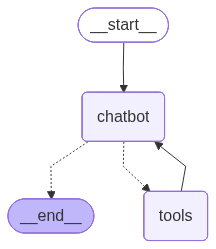

In [31]:
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
def chat(user_input:str,history):
    result = graph.invoke({"messages":[{"role":"user","content":user_input}]})
    return result["messages"][-1].content
gr.ChatInterface(chat).launch(share=True)

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://1e11ce77ac8dda01f3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [23]:
for t in tools:
    print(t.name)

search
send push notification


### using langgraph memory

In [9]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [16]:
#step2:
graph_builder=StateGraph(State)
#step3:
llm=ChatOpenAI(model="gpt-4o-mini")
llm_with_tools=llm.bind_tools(tools)

def chatbot_with_lgmemory(state:State):
    print(state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot",chatbot_with_lgmemory)
graph_builder.add_node("tools",ToolNode(tools=tools))


In [17]:
#step4:
graph_builder.add_conditional_edges("chatbot",tools_condition,"tools")
graph_builder.add_edge("tools","chatbot")
graph_builder.add_edge(START,"chatbot")

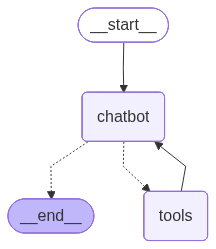

In [18]:
#step5:
graph=graph_builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
config = {"configurable" : {"thread_id" : "1"}}

def chat(user_input:str,history):
    result = graph.invoke({"messages" : [{"role":"user","content":user_input}]},config=config)
    return result["messages"][-1].content
gr.ChatInterface(chat).launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://e633bc43ca2e558867.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


{'messages': [HumanMessage(content='send me a usd rate today ', additional_kwargs={}, response_metadata={}, id='5dc13448-8a58-4c12-a441-2dd57d18f1ae')]}
{'messages': [HumanMessage(content='send me a usd rate today ', additional_kwargs={}, response_metadata={}, id='5dc13448-8a58-4c12-a441-2dd57d18f1ae'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 81, 'total_tokens': 99, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_579e46069f', 'id': 'chatcmpl-DZjzz4UV7NF0KQHTu9eI2zBGdtGrZ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dd5ee-7dbe-7151-b03e-bcf90cdb8f0a-0', tool_calls=[{'name': 'search', 'args': {'__a

In [21]:
graph.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='send me a usd rate today ', additional_kwargs={}, response_metadata={}, id='5dc13448-8a58-4c12-a441-2dd57d18f1ae'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 81, 'total_tokens': 99, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_579e46069f', 'id': 'chatcmpl-DZjzz4UV7NF0KQHTu9eI2zBGdtGrZ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dd5ee-7dbe-7151-b03e-bcf90cdb8f0a-0', tool_calls=[{'name': 'search', 'args': {'__arg1': 'current USD exchange rate'}, 'id': 'call_guMqt39AYBzrAsavEn338cnJ', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metad

In [22]:
list(graph.get_state_history(config))

[StateSnapshot(values={'messages': [HumanMessage(content='send me a usd rate today ', additional_kwargs={}, response_metadata={}, id='5dc13448-8a58-4c12-a441-2dd57d18f1ae'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 81, 'total_tokens': 99, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_579e46069f', 'id': 'chatcmpl-DZjzz4UV7NF0KQHTu9eI2zBGdtGrZ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dd5ee-7dbe-7151-b03e-bcf90cdb8f0a-0', tool_calls=[{'name': 'search', 'args': {'__arg1': 'current USD exchange rate'}, 'id': 'call_guMqt39AYBzrAsavEn338cnJ', 'type': 'tool_call'}], invalid_tool_calls=[], usage_meta

In [27]:
import langgraph
print(dir(langgraph))
import langgraph.checkpoint as cp
print(dir(cp))

['__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_internal', 'cache', 'callbacks', 'channels', 'checkpoint', 'config', 'constants', 'errors', 'graph', 'managed', 'prebuilt', 'pregel', 'runtime', 'store', 'types', 'typing', 'warnings']
['__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'base', 'memory', 'serde']
